Logistic_Regression is a regression used for **classification**

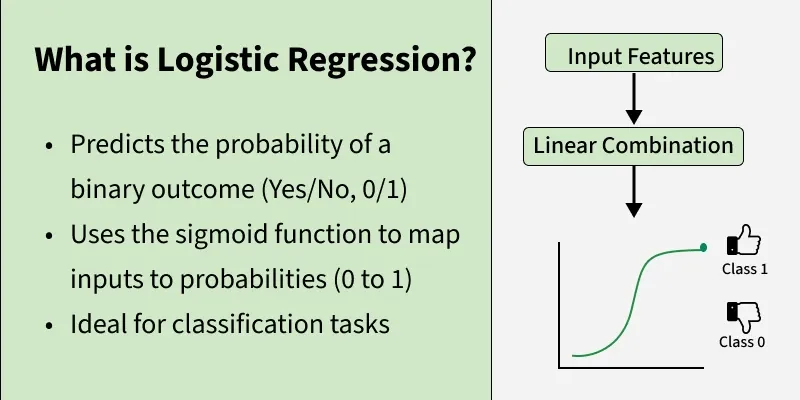

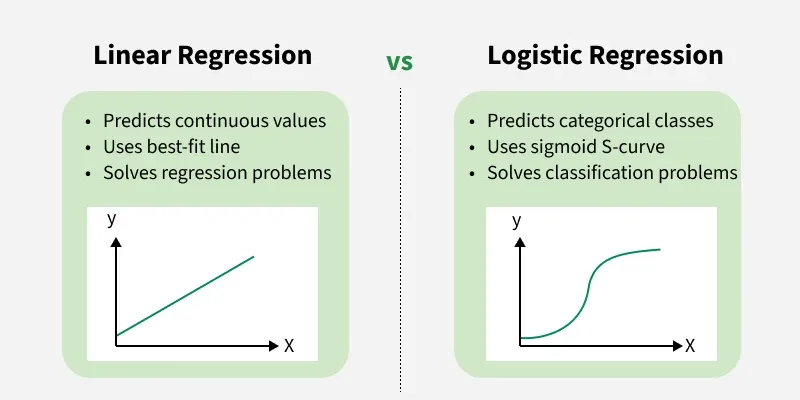

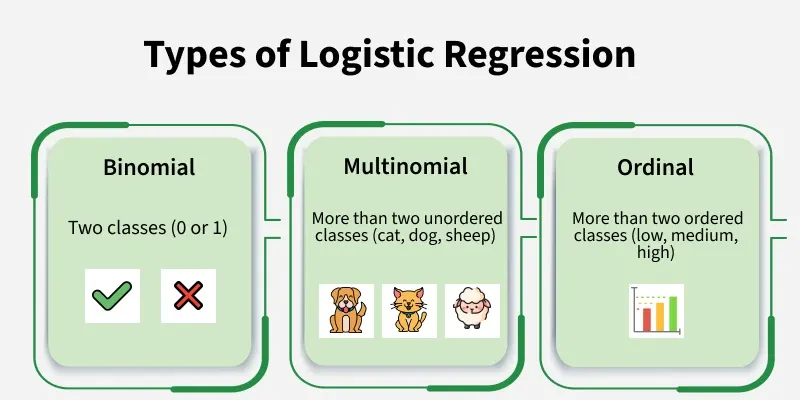

In [28]:
#Import Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import zero_one_loss

In [ ]:
BreastData = load_breast_cancer()
X = BreastData.data
y = BreastData.target

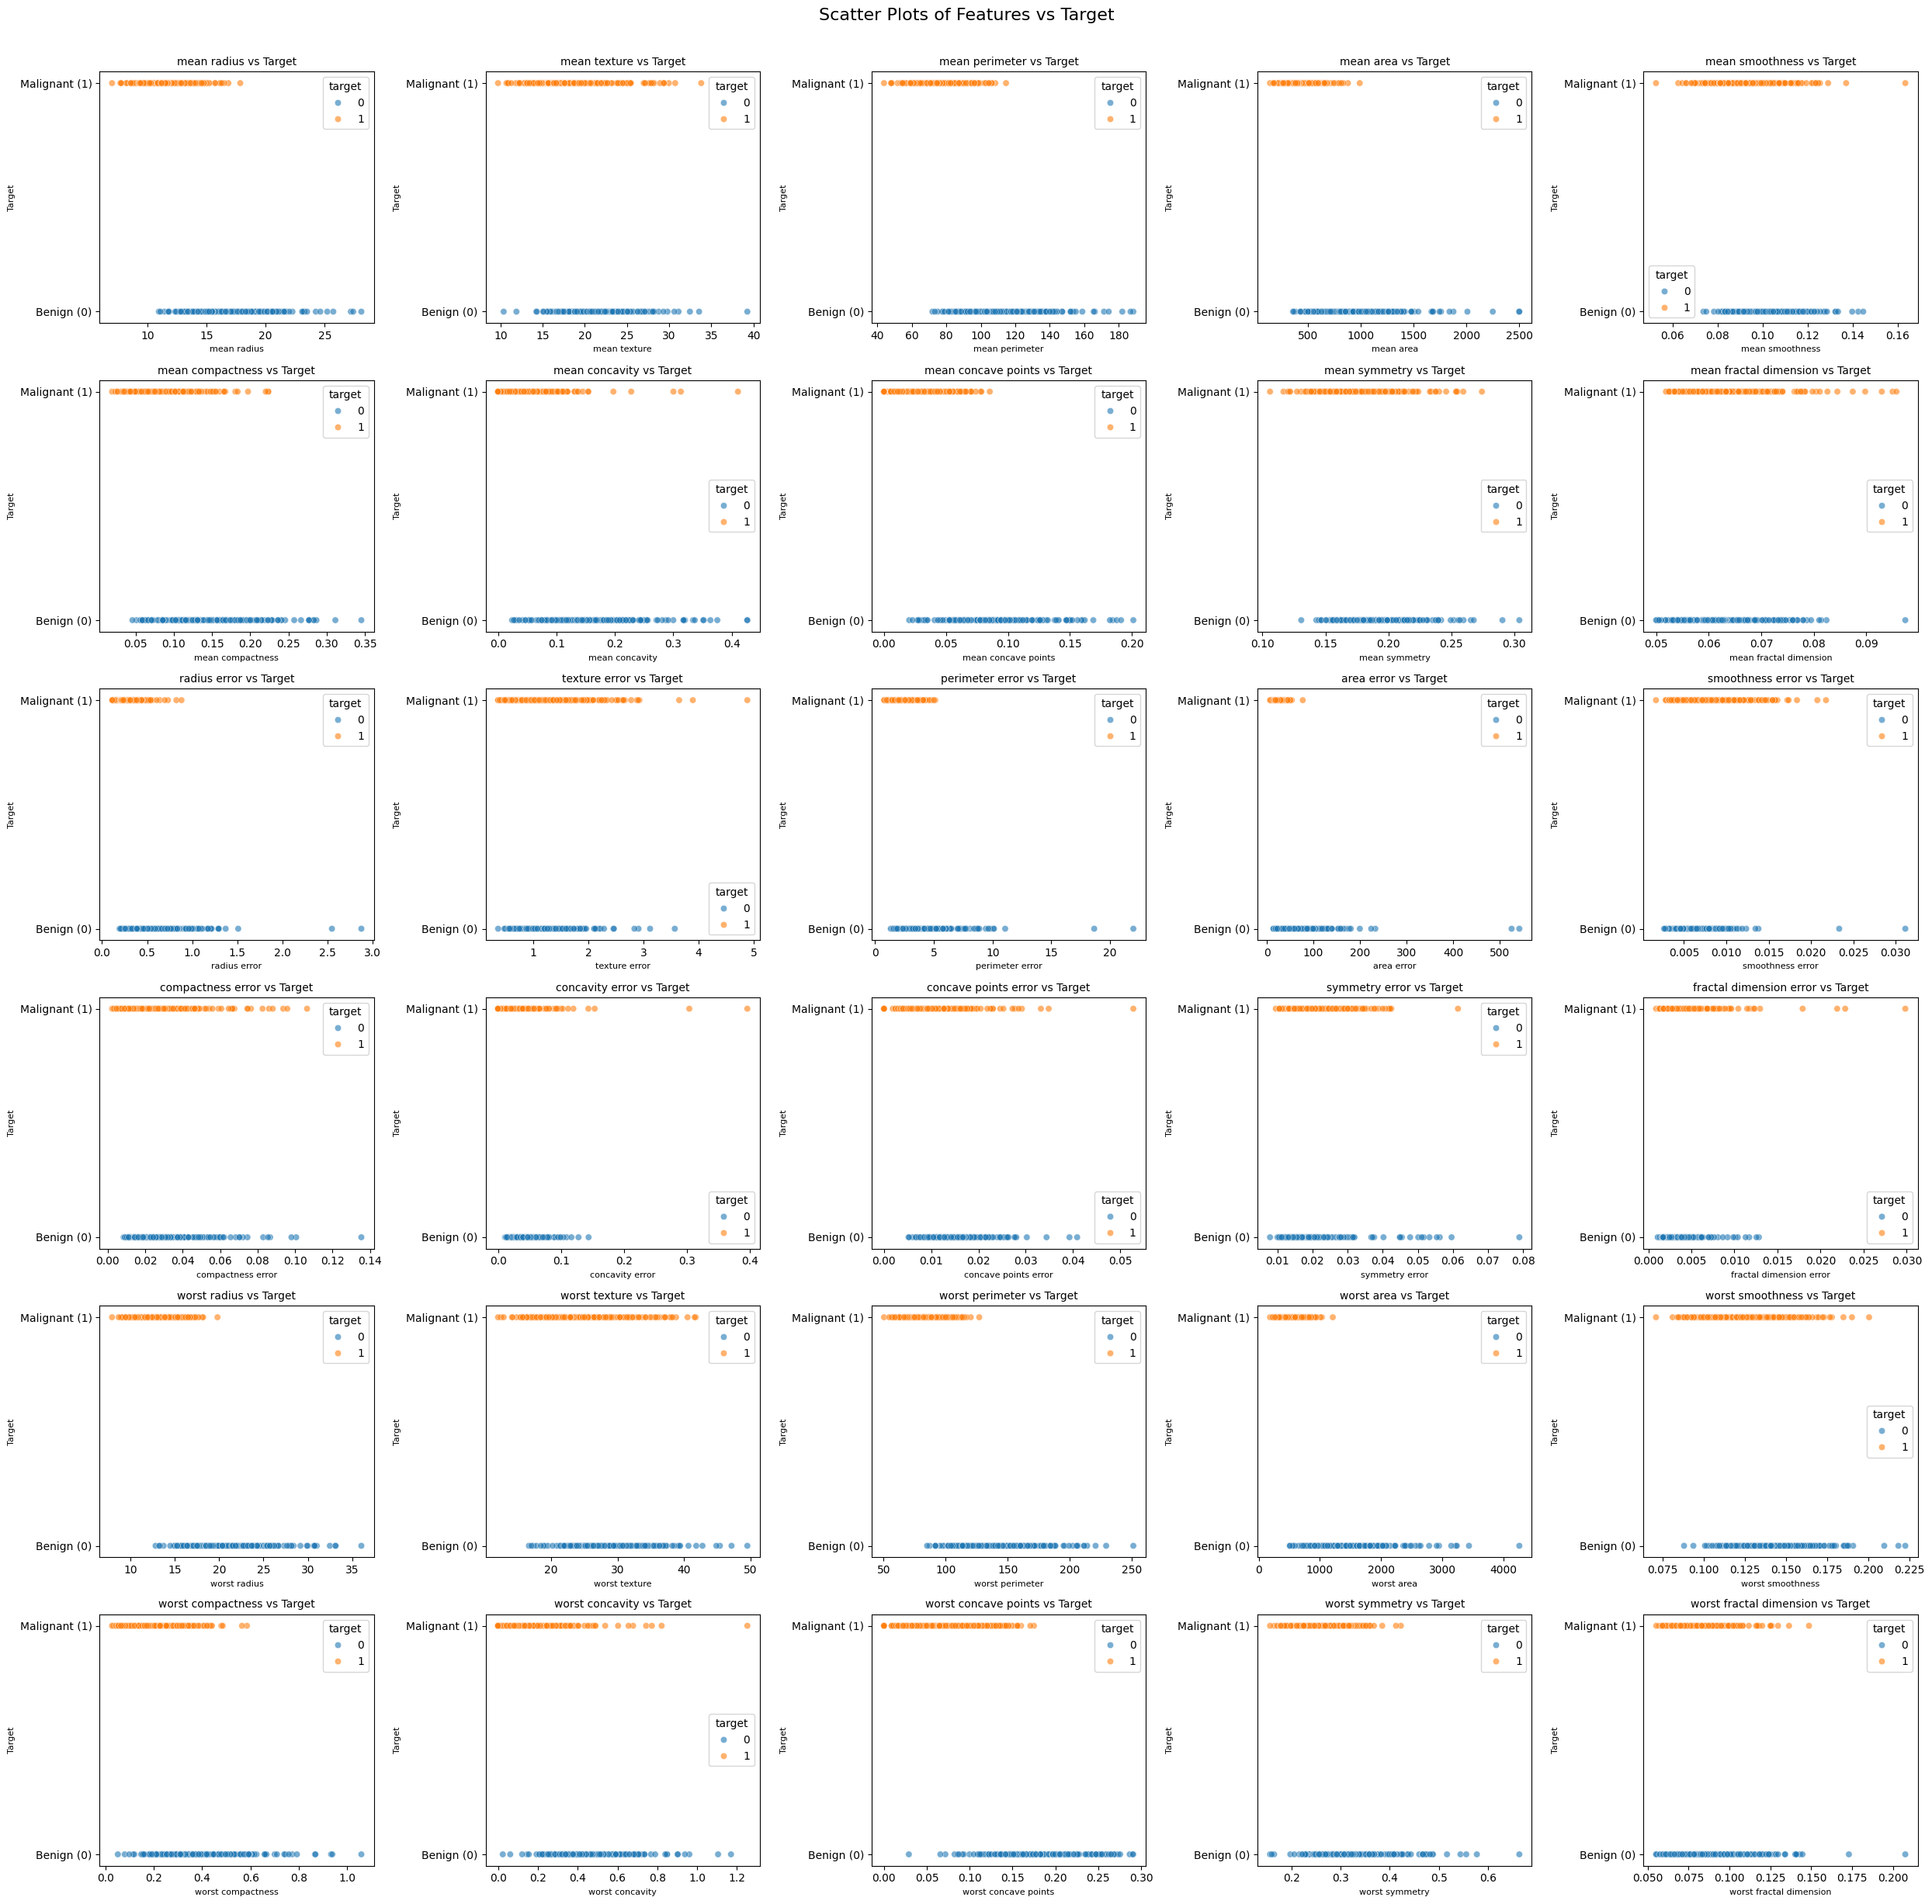

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already defined from previous cells and contains 'target' column

feature_names = BreastData.feature_names # Get feature names
n_features = len(feature_names)

# Determine grid size for subplots (e.g., 5 columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    sns.scatterplot(x=df[feature_name], y=df['target'], hue=df['target'], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature_name} vs Target', fontsize=10)
    axes[i].set_xlabel(feature_name, fontsize=8)
    axes[i].set_ylabel('Target', fontsize=8)
    axes[i].set_yticks([0, 1]) # Set y-ticks for binary target
    axes[i].set_yticklabels(['Benign (0)', 'Malignant (1)']) # Label y-ticks

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Scatter Plots of Features vs Target', y=1.02, fontsize=16)
plt.show()

In [ ]:
import numpy as np
print("Null values in X:", np.isnan(X).sum())
print("Null values in y:", np.isnan(y).sum())

Null values in X: 0
Null values in y: 0


In [ ]:
import numpy as np

print(f"Data type of X: {X.dtype}")
print(f"Is X fully numerical? {np.issubdtype(X.dtype, np.number)}")
print(f"Data type of y: {y.dtype}")
print(f"Is y fully numerical? {np.issubdtype(y.dtype, np.number)}")

Data type of X: float64
Is X fully numerical? True
Data type of y: int64
Is y fully numerical? True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.33,
                                                    random_state=44,
                                                    shuffle=True)

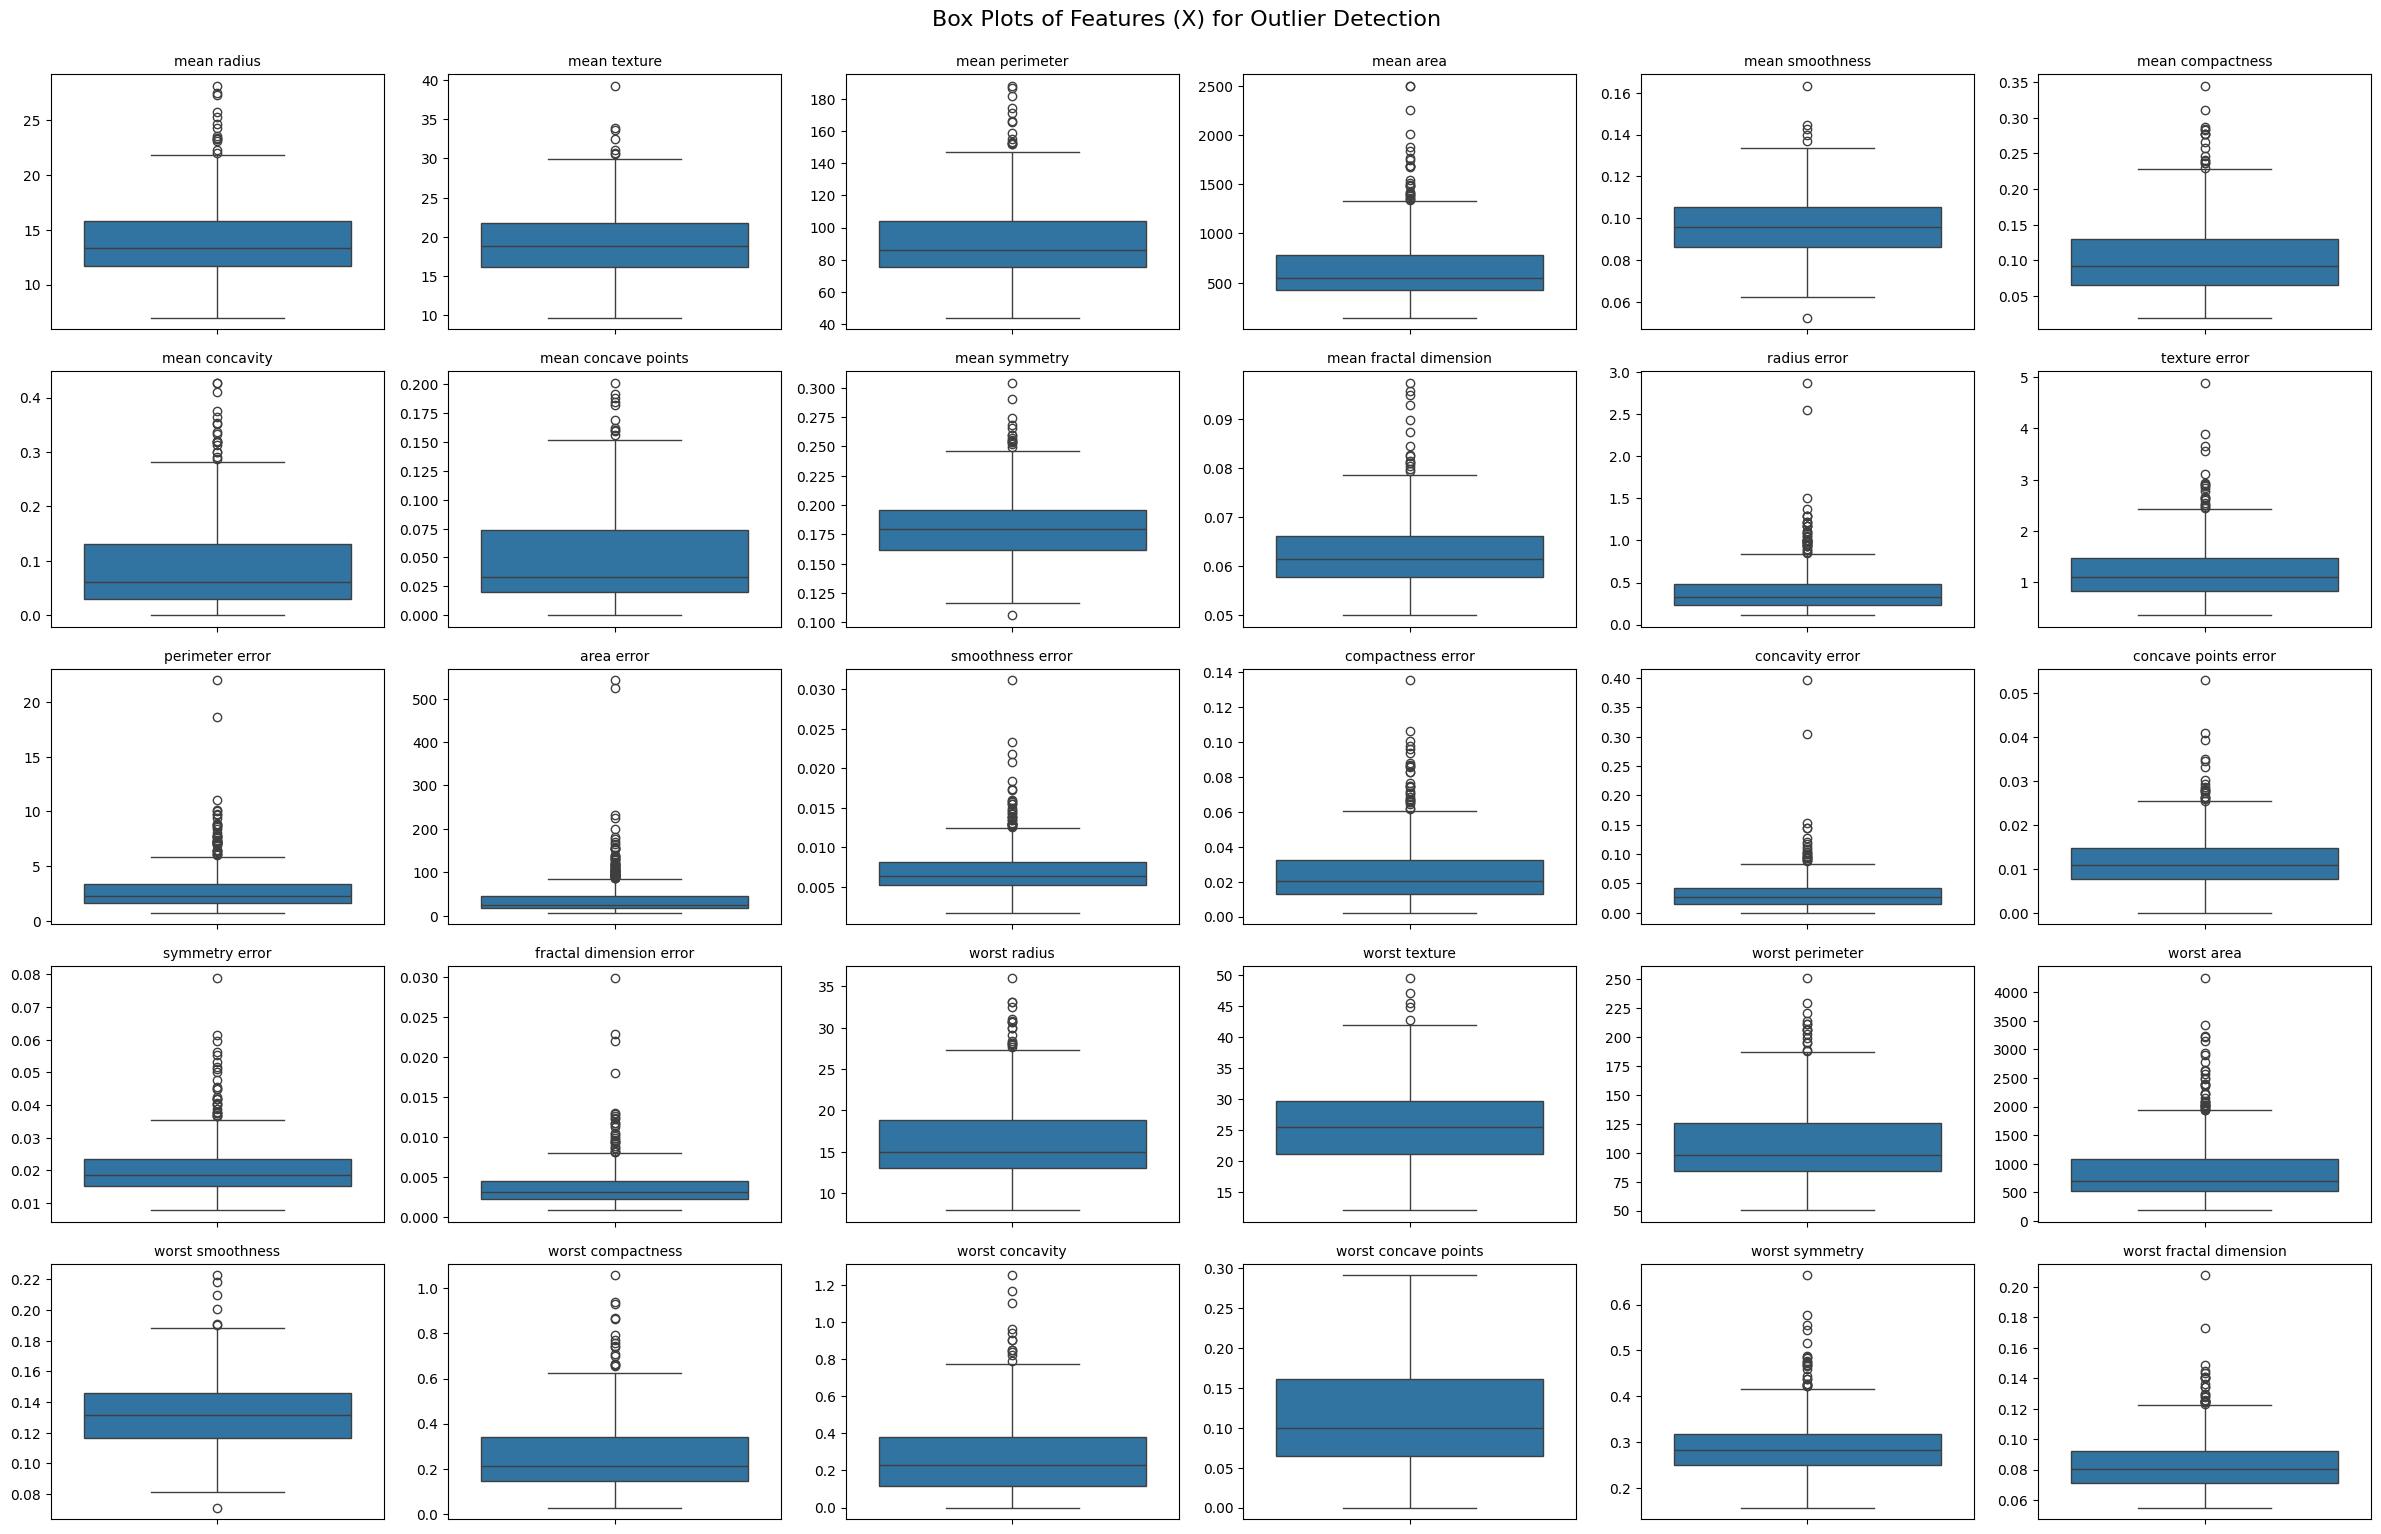

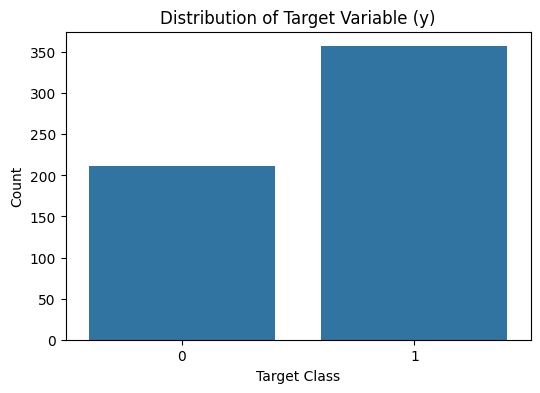

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# No pandas import is needed if we're not creating df_X

# Use BreastData.feature_names directly for feature names
features = BreastData.feature_names
n_features = len(features)

# Determine grid size for subplots (e.g., 6 columns)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feature_name in enumerate(features):
    # Plot directly from the X NumPy array using column index
    sns.boxplot(y=X[:, i], ax=axes[i])
    axes[i].set_title(feature_name, fontsize=10) # Set title using feature_name
    axes[i].set_ylabel('') # Remove y-label to avoid clutter

# Remove any unused subplots if the number of features doesn't fill the grid perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box Plots of Features (X) for Outlier Detection', y=1.02, fontsize=16)
plt.show()

# Visualize y distribution (since y is categorical, a count plot is more appropriate)
plt.figure(figsize=(6, 4))
sns.countplot(x=y) # Use y directly
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the training features (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to the test features (X_test)
X_test_scaled = scaler.transform(X_test)


Applying IQR-based capping for outliers...
Outliers capped successfully in X_train_scaled and X_test_scaled.
Shape of X_train_scaled after capping: (381, 30)
Shape of X_test_scaled after capping: (188, 30)


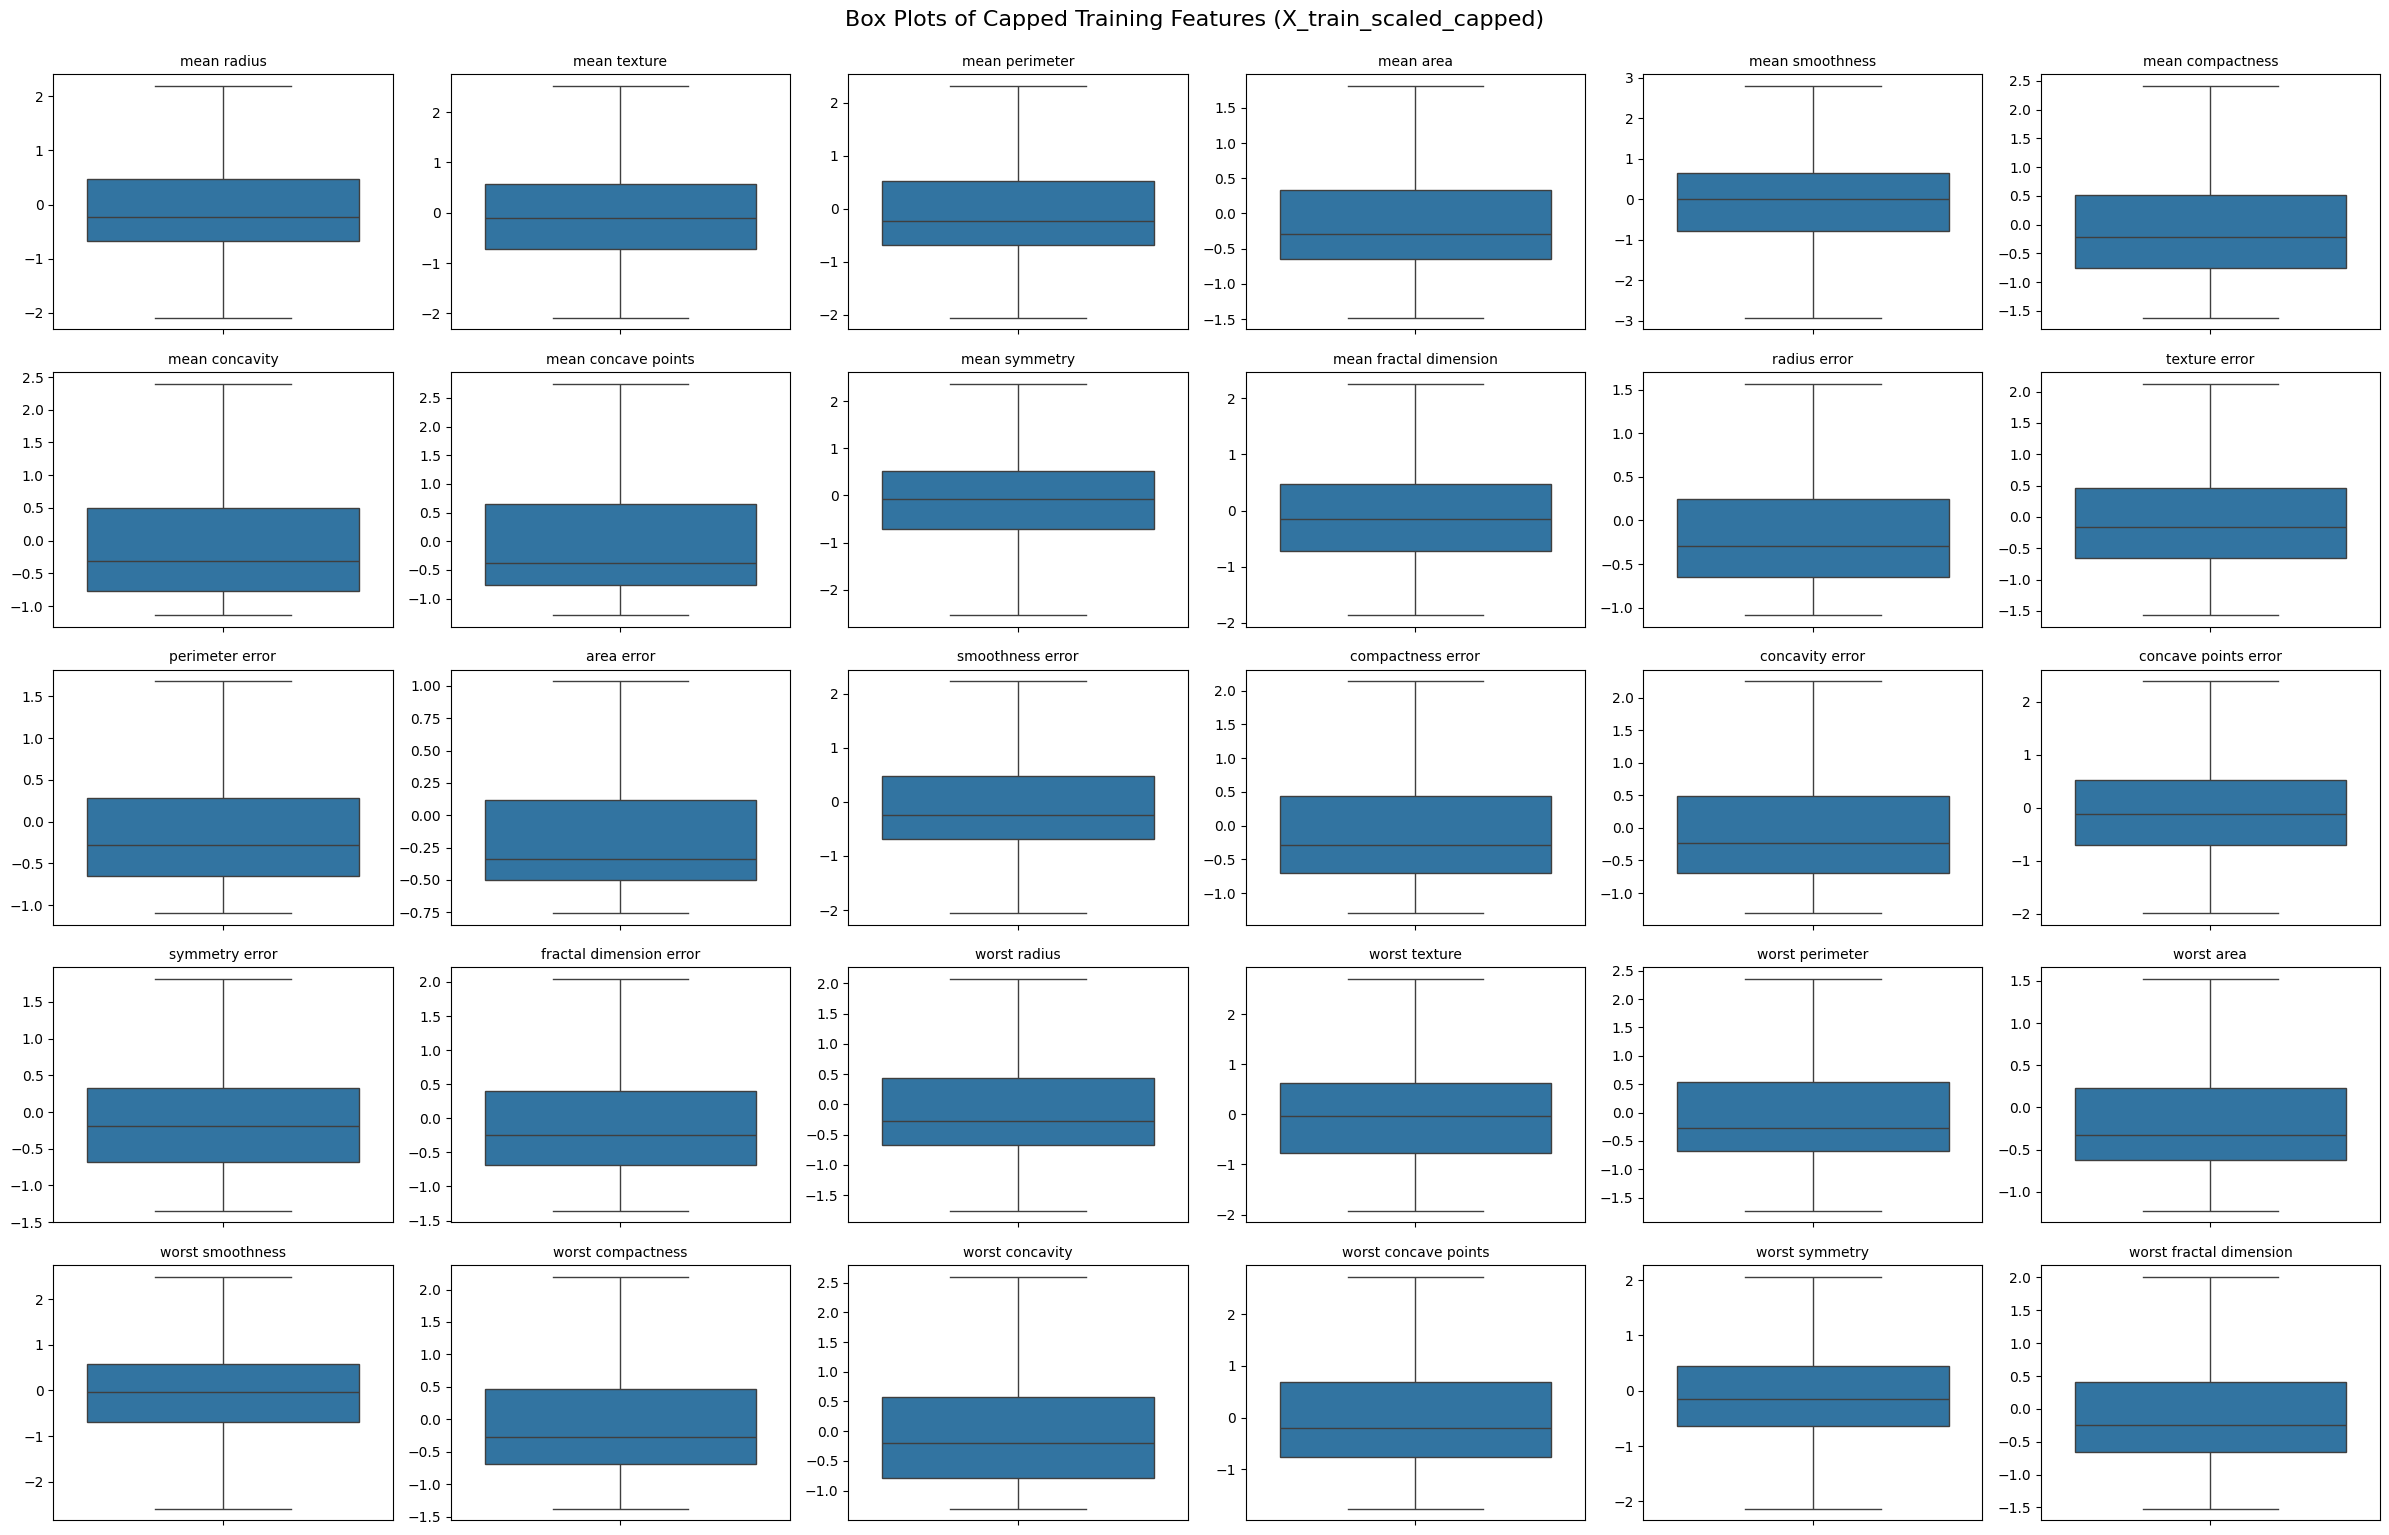

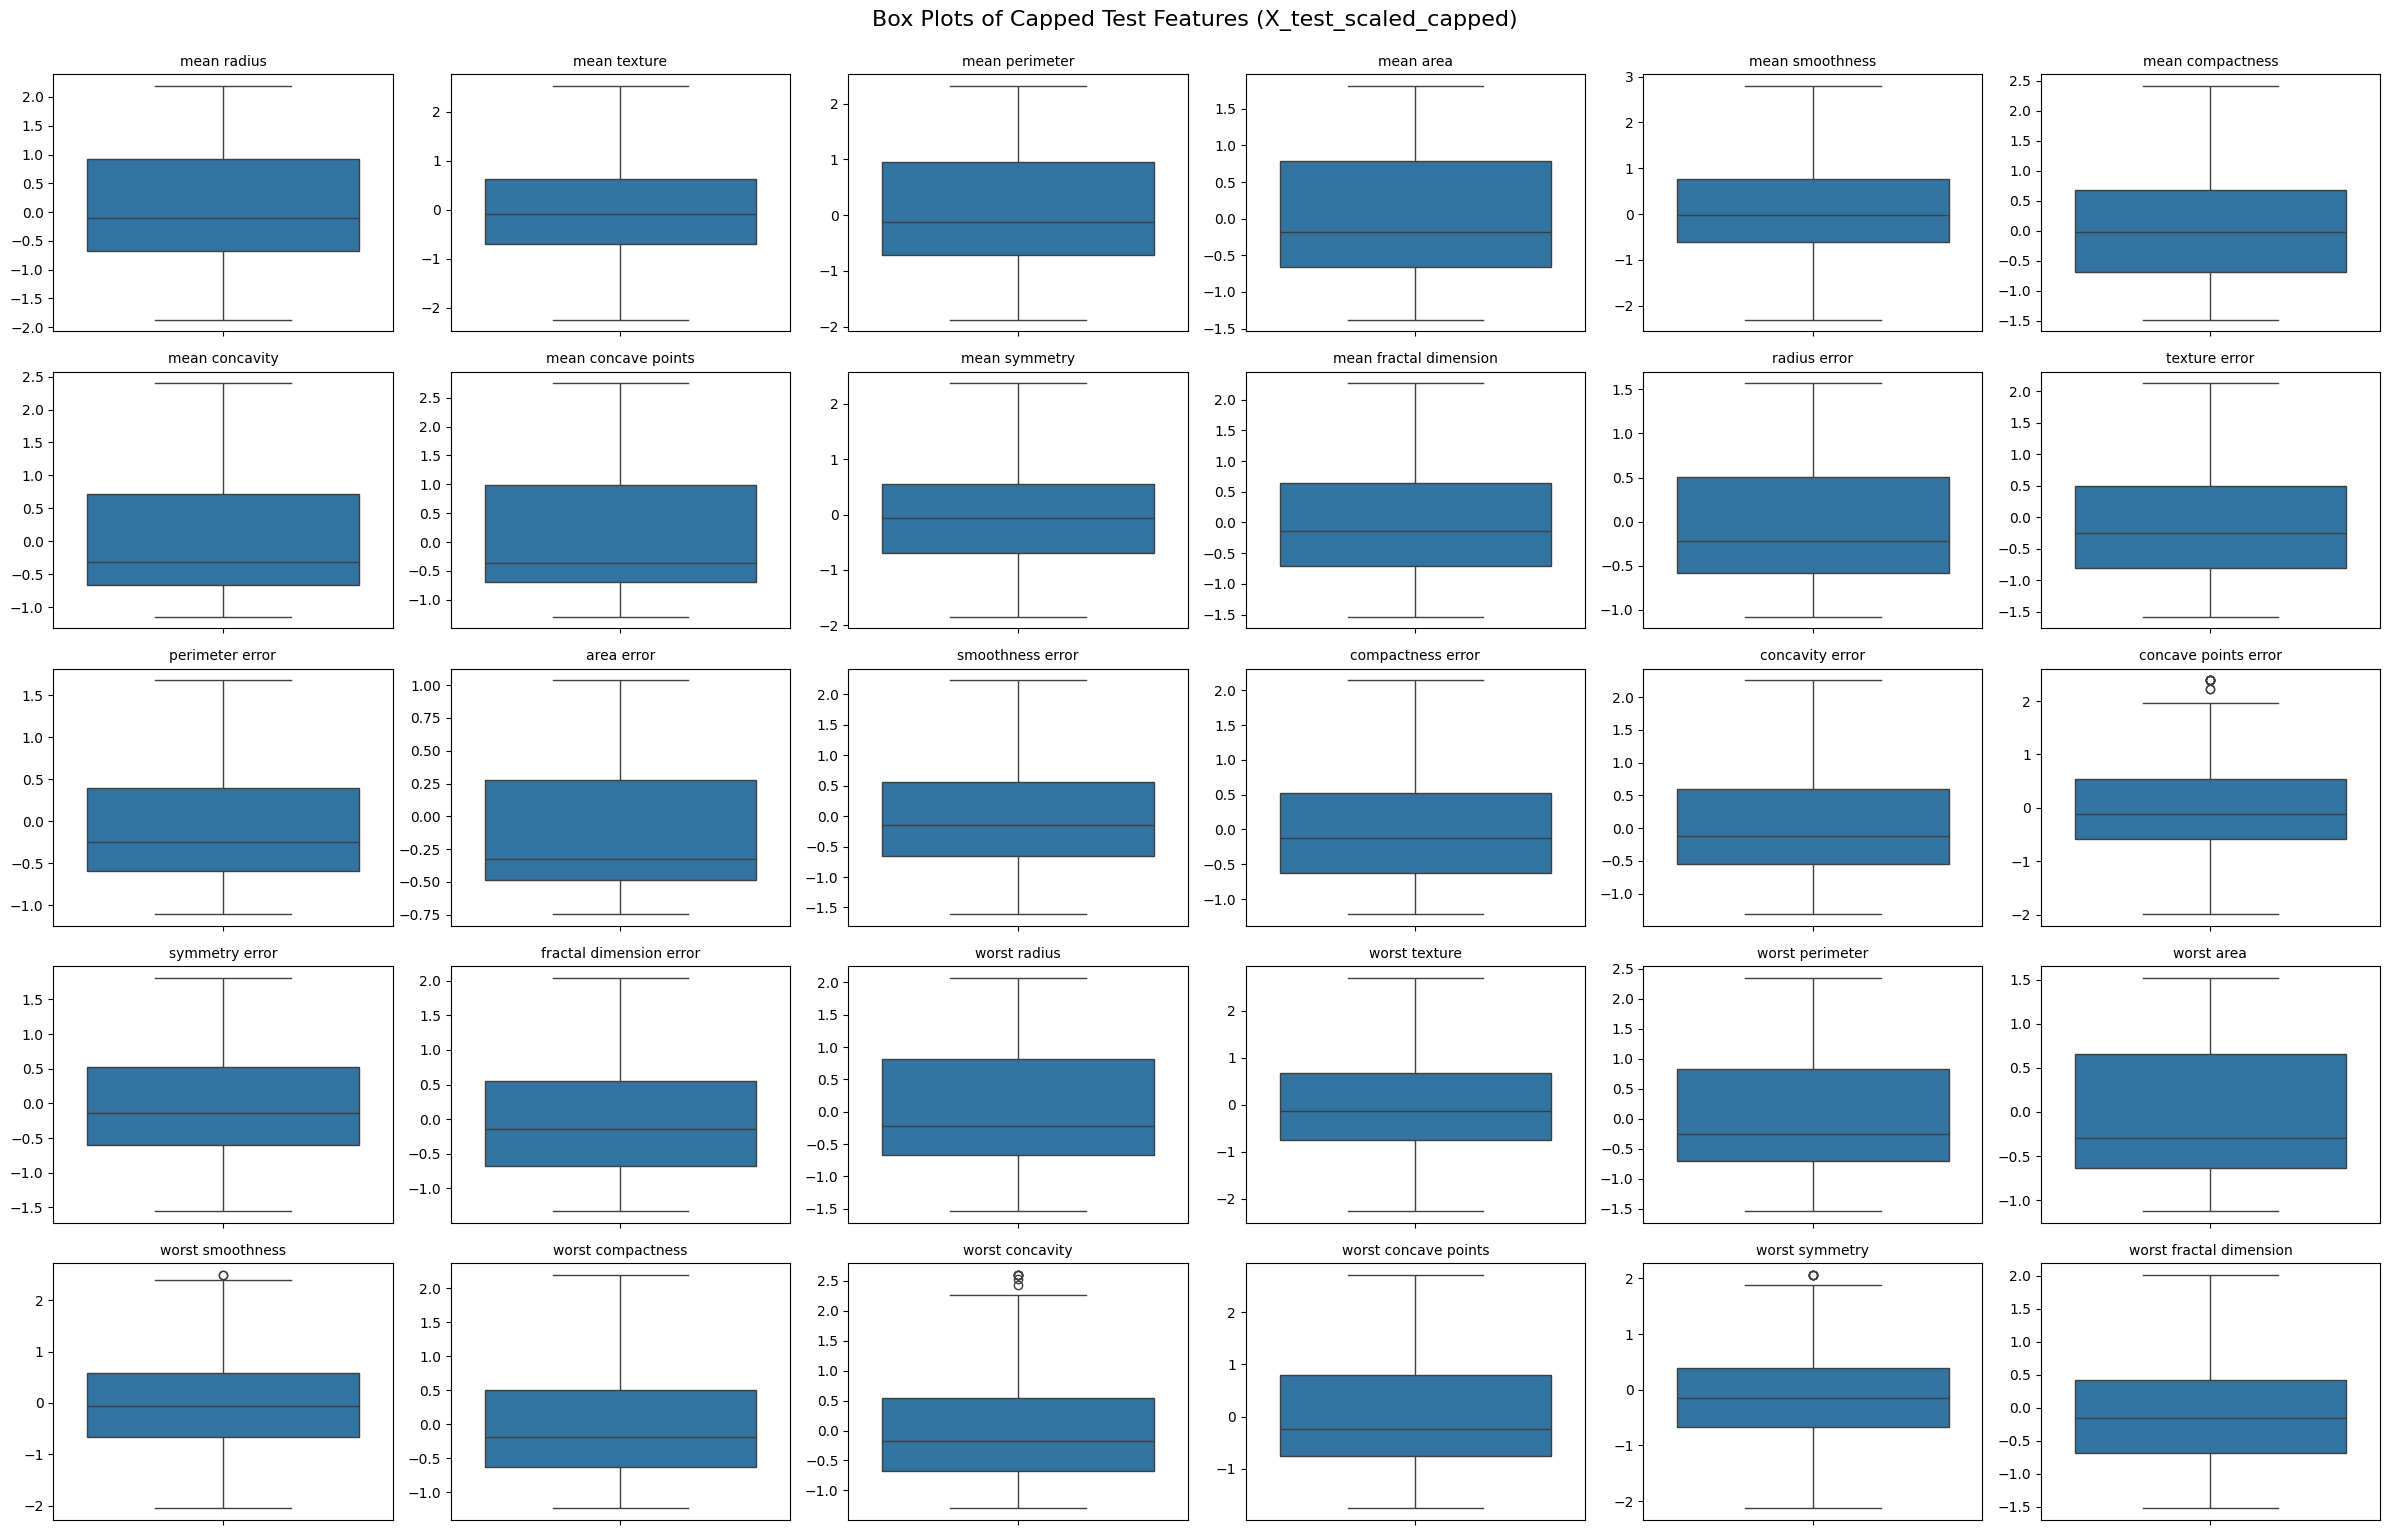

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# pandas is no longer needed for this cell as we're working directly with numpy arrays

# Create copies of the scaled NumPy arrays for capping
X_train_capped = X_train_scaled.copy()
X_test_capped = X_test_scaled.copy()

print("Applying IQR-based capping for outliers...")

# Get feature names from BreastData for labeling plots
feature_names = BreastData.feature_names
n_features = len(feature_names)

for i in range(n_features):
    # Calculate Q1, Q3, and IQR for each feature using np.percentile on the training data
    Q1 = np.percentile(X_train_capped[:, i], 25)
    Q3 = np.percentile(X_train_capped[:, i], 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping to training data (replace values outside bounds)
    X_train_capped[:, i] = np.where(X_train_capped[:, i] < lower_bound, lower_bound,
                                    np.where(X_train_capped[:, i] > upper_bound, upper_bound,
                                             X_train_capped[:, i]))

    # Apply capping to test data using bounds learned from training data
    X_test_capped[:, i] = np.where(X_test_capped[:, i] < lower_bound, lower_bound,
                                   np.where(X_test_capped[:, i] > upper_bound, upper_bound,
                                            X_test_capped[:, i]))

print("Outliers capped successfully in X_train_scaled and X_test_scaled.")

print(f"Shape of X_train_scaled after capping: {X_train_capped.shape}")
print(f"Shape of X_test_scaled after capping: {X_test_capped.shape}")

# --- Visualize the effect of capping with new box plots ---

n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

# Plotting box plots for X_train_capped
fig_train_capped, axes_train_capped = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes_train_capped = axes_train_capped.flatten()

for i in range(n_features):
    sns.boxplot(y=X_train_capped[:, i], ax=axes_train_capped[i])
    axes_train_capped[i].set_title(feature_names[i], fontsize=10)
    axes_train_capped[i].set_ylabel('')

# Remove any unused subplots
for j in range(n_features, len(axes_train_capped)):
    fig_train_capped.delaxes(axes_train_capped[j])

plt.tight_layout()
plt.suptitle('Box Plots of Capped Training Features (X_train_scaled_capped)', y=1.02, fontsize=16)
plt.show()

# Plotting box plots for X_test_capped
fig_test_capped, axes_test_capped = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes_test_capped = axes_test_capped.flatten()

for i in range(n_features):
    sns.boxplot(y=X_test_capped[:, i], ax=axes_test_capped[i])
    axes_test_capped[i].set_title(feature_names[i], fontsize=10)
    axes_test_capped[i].set_ylabel('')

# Remove any unused subplots
for j in range(n_features, len(axes_test_capped)):
    fig_test_capped.delaxes(axes_test_capped[j])

plt.tight_layout()
plt.suptitle('Box Plots of Capped Test Features (X_test_scaled_capped)', y=1.02, fontsize=16)
plt.show()


In [ ]:
logistic_regression = LogisticRegression(penalty='l2',
                                         solver = 'sag',
                                         C=0.5,
                                         random_state=33,
                                         max_iter=1000,
                                         tol = 0.01)
logistic_regression.fit(X_train, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=33, solver='sag',
                   tol=0.01)

In [ ]:
print("train score:",logistic_regression.score(X_train, y_train))
print("test score: ",logistic_regression.score(X_test, y_test))
print("classes: ",logistic_regression.classes_)
print("no of iterations: ",logistic_regression.n_iter_)

train score: 0.8923884514435696
test score:  0.925531914893617
classes:  [0 1]
no of iterations:  [63]


In [ ]:
y_pred = logistic_regression.predict(X_test)
y_pred_prob = logistic_regression.predict_proba(X_test)

print(y_pred_prob[:5])

[[9.16511194e-01 8.34888060e-02]
 [9.15462982e-01 8.45370185e-02]
 [2.11141205e-01 7.88858795e-01]
 [9.99116210e-01 8.83790204e-04]
 [3.08360388e-01 6.91639612e-01]]


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm )

[[ 56  12]
 [  2 118]]


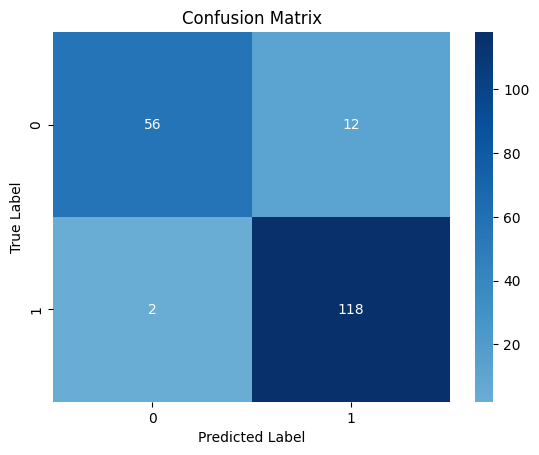

In [ ]:
sns.heatmap(cm, center=True, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_score = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F-score: {f_score:.4f}")

Precision: 0.9077
Recall: 0.9833
F-score: 0.9440


In [ ]:
y_pred_train = logistic_regression.predict(X_train)

print("Classification Report for Training Set:")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred))

Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       144
           1       0.88      0.96      0.92       237

    accuracy                           0.89       381
   macro avg       0.90      0.87      0.88       381
weighted avg       0.90      0.89      0.89       381


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89        68
           1       0.91      0.98      0.94       120

    accuracy                           0.93       188
   macro avg       0.94      0.90      0.92       188
weighted avg       0.93      0.93      0.92       188

